# XGBoost

This notebook explores the XGBoost model. First, GridSearchCV is used to tune an XGB model using all of the available data to train and test the model. Then, the same process is used but with a selection of features omitted. Each feature combination is tried and the best one selected. In this case, the 'best' refers to the model with the greatest accuracy. The importance of each feature is then assessed. All of this is done using a specified random seed to ensure the results are reproducible.

The optimum model uses just 2 features of the available 6: 
- X1 (importance 0.62)
- X5 (importance 0.38)

It has the following hyperparameters:
- Learning rate: 0.01
- Max depth: 3
- n estimators: 100

It achieved the following metrics:
- Accuracy: 0.81
- Recall: 0.80
- Precision: 0.81
- F1: 0.81

Therefore the model performs sufficiently well as a predictor for a customers happiness, and it does so using just 2 features, meaning the others are redundant and need not be collated. This makes the data collection process simpler and easier.

In [22]:
# change directory to the repository
import os
os.chdir(r"C:\Users\mattc\OneDrive\Documents\eso8GKofnumUkahs")
os.getcwd()

'C:\\Users\\mattc\\OneDrive\\Documents\\eso8GKofnumUkahs'

In [23]:
# import all the necessary libraries
import numpy as np
import pandas as pd
from IPython.display import display, Markdown
from matplotlib import pyplot as plt
from xgboost import XGBClassifier
from itertools import combinations
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit, train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score, classification_report, make_scorer
from src.data.prepare_data import x_y_split

In [36]:
# choose a random state to set across the notebook to ensure the results are repeatable
random_state = 42
np.random.seed(random_state)
print('Random Seed:')
print(random_state)

Random Seed:
42


In [25]:
# import the data and split it into x and y (features and target)
data = pd.read_csv('data/raw/ACME-HappinessSurvey2020.csv')
x, y = x_y_split(data)

In [28]:
display(Markdown('### XGBoost Model with GridSearchCV'))
display(Markdown('Training and XGBoost model using GridSearchCV to try various hyperparameter combinations and cross-validate the training data. Assessing the models with accuracy being the priority metric. Feature importance displayed.'))

### XGBoost Model with GridSearchCV

Training and XGBoost model using GridSearchCV to try various hyperparameter combinations and cross-validate the training data. Assessing the models with accuracy being the priority metric. Feature importance displayed.

Fitting 3 folds for each of 27 candidates, totalling 81 fits


### XGB Classifier Report

Best Parameters:
{'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 100}
Testing Data Accuracy:
0.54
              precision    recall  f1-score   support

           0       0.50      0.42      0.45        12
           1       0.56      0.64      0.60        14

    accuracy                           0.54        26
   macro avg       0.53      0.53      0.53        26
weighted avg       0.53      0.54      0.53        26



### Confusion Matrix

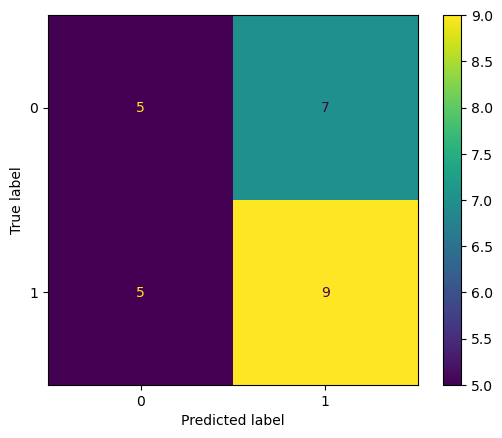

### Feature Importance

,Feature,Importance
0,X1,0.215
2,X3,0.199
5,X6,0.196
4,X5,0.142
3,X4,0.130
1,X2,0.118


In [29]:
# splitting the data into training and testing, using the random state from above and stratifying to keep the target ratio
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=random_state, stratify=y)

# hyperparameter options to try
param_grid = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [2, 3, 5]
}

# performing the grid search, with the random state from above and optimising for accuracy
xgb_grid = GridSearchCV(
    XGBClassifier(random_state=random_state),
    param_grid,
    cv=3, 
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

# fitting the grid to the training data, selecting the best model and using it to make predicions based on the testing data
xgb_grid.fit(x_train, y_train)
xgb_model = xgb_grid.best_estimator_
y_pred = xgb_model.predict(x_test)

# displaying the models performance
display(Markdown('### XGB Classifier Report'))

# the hyperparameter combination of the best model
print('Best Parameters:')
print(xgb_grid.best_params_)

# the accuracy of the predicitons compared to the testing data
print('Testing Data Accuracy:')
print(round(accuracy_score(y_test, y_pred), 2))

# the full classification report with a breakdown of various metrics
print(classification_report(y_test, y_pred))

# confusion matrix, displaying true and false positives and negatives
display(Markdown('### Confusion Matrix'))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

# feature importance table, showing how significant each features contribution was to the predictions
importance = pd.DataFrame({
    'Feature': x_train.columns,
    'Importance': xgb_model.feature_importances_.round(3)
})
importance = importance.sort_values('Importance', ascending=False)
display(Markdown('### Feature Importance'))
display(importance)

In [31]:
display(Markdown('### Feature Selection'))
display(Markdown('The same as above, training an XGBoost model with hyperparameter tuning and cross-validation. However, each different combination of features is tried to see if accuracy can be improved. For the best combination of features, the model is built again and then the performance metrics, confusion matrix and feature importance table are all displayed.'))

### Feature Selection

The same as above, training an XGBoost model with hyperparameter tuning and cross-validation. However, each different combination of features is tried to see if accuracy can be improved. For the best combination of features, the model is built again and then the performance metrics, confusion matrix and feature importance table are all displayed.

### XGB Classifier Report with Feature Selection

Best Feature Combination:
['X1', 'X5']
Feature Combination Table (Top 5)


,Features,Accuracy,n_features
0,"(X1, X5)",0.808,2
1,"(X1, X2, X5)",0.808,3
2,"(X1, X4, X5)",0.808,3
3,"(X1, X5, X6)",0.808,3
4,"(X1, X2, X5, X6)",0.808,4


Best Parameters:
{'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100}
Testing Data Accuracy:
0.81
              precision    recall  f1-score   support

           0       0.82      0.75      0.78        12
           1       0.80      0.86      0.83        14

    accuracy                           0.81        26
   macro avg       0.81      0.80      0.81        26
weighted avg       0.81      0.81      0.81        26



### Confusion Matrix

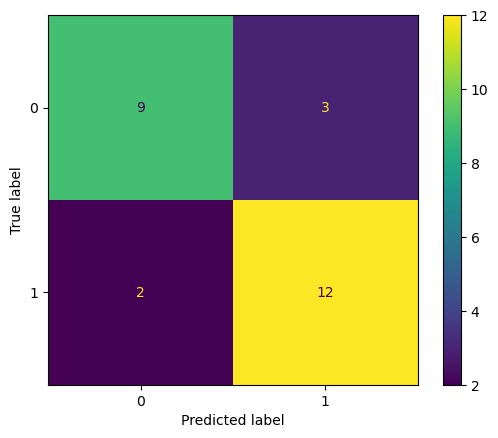

### Feature Importance

,Feature,Importance
0,X1,0.619
1,X5,0.381


In [38]:
# splitting the data into training and testing, using the random state from above and stratifying to keep the target ratio
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

# hyperparameter options to try
param_grid = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [2, 3, 5]
}

# list of features
features = x.columns
# blank dict to store the accuracy score from each feature combination
results = {}

# iterating through each combination of features, tuning an xgb model each time
for r in range(1, len(features) + 1):
    for feature_subset in combinations(features, r):
        x_train_subset = x_train[list(feature_subset)]
        x_test_subset = x_test[list(feature_subset)]

        # tune the model to find the best hyperparameters, optimising for accuracy
        xgb_grid = GridSearchCV(
            XGBClassifier(random_state=random_state),
            param_grid,
            cv=5, 
            scoring='accuracy',
            n_jobs=-1,
            verbose=0
        )

        # fitting the grid to the subset of training features, finding the best model, predicting the y values
        xgb_grid.fit(x_train_subset, y_train)
        xgb_model = xgb_grid.best_estimator_
        y_pred = xgb_model.predict(x_test_subset)

        # storing the accuracy associated with the feature combination
        results[feature_subset] = round(accuracy_score(y_test, y_pred), 3)

# turning the results into a dataframe, sorted by accuracy (desc) first, then number of features (asc)
results_df = pd.DataFrame(
    results.items(),
    columns=['Features', 'Accuracy']
)
results_df['n_features'] = results_df['Features'].apply(len)
results_df = results_df.sort_values(
    ['Accuracy', 'n_features'],
    ascending=[False, True]
).reset_index(drop=True)
# identifying which feature combination achieved the best accuracy with the fewest features
best_features = list(results_df.iloc[0]['Features'])

# re-tuning the xgb model using the best feature combination
xgb_grid = GridSearchCV(
    XGBClassifier(random_state=random_state),
    param_grid,
    cv=5, 
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)
x_drop = x[best_features]
x_train_drop, x_test_drop, y_train, y_test = train_test_split(x_drop, y, test_size=0.2, random_state=42, stratify=y)
xgb_grid.fit(x_train_drop, y_train)
xgb_model = xgb_grid.best_estimator_
y_pred = xgb_model.predict(x_test_drop)

# displaying the performance of the final chosen model
display(Markdown('### XGB Classifier Report with Feature Selection'))

print('Best Feature Combination:')
print(best_features)

print('Feature Combination Table (Top 5)')
display(results_df.head(5))

print('Best Parameters:')
print(xgb_grid.best_params_)

print('Testing Data Accuracy:')
print(round(accuracy_score(y_test, y_pred), 2))

print(classification_report(y_test, y_pred))

display(Markdown('### Confusion Matrix'))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

importance = pd.DataFrame({
    'Feature': x_train_drop.columns,
    'Importance': xgb_model.feature_importances_.round(3)
})
importance = importance.sort_values('Importance', ascending=False)
display(Markdown('### Feature Importance'))
display(importance)